In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [3]:
def load_agriculture_data():    
    ag_data = pd.read_csv("X:/AI DataScience projects/Assignment 8/capstone-project-KarunBhandari/Weather_&_Climate_Data/Processed Datas/transformed_agriculture_data.csv")
    ag_data.info()
    ag_data.head()
    print(ag_data.isna().sum())
    ag_data.describe()
    return ag_data

In [4]:
ag_data = load_agriculture_data()
if ag_data.isna().any().any():
    indices_to_drop = [0, 1, ag_data.index[-1]]
    existing_indices = [i for i in indices_to_drop if i in ag_data.index]
    ag_data = ag_data.drop(index=existing_indices)

# Ensure 'Year' is integer
ag_data['Year'] = ag_data['Year'].astype(int)

# Loop through each 10-year interval
for start_year in range(ag_data['Year'].min(), ag_data['Year'].max() + 1, 10):
    end_year = start_year + 9
    decade_data = ag_data[(ag_data['Year'] >= start_year) & (ag_data['Year'] <= end_year)]
    
    if not decade_data.empty:
        fig = px.scatter_matrix(
            decade_data,
            dimensions=[
                "Agricultural_land_pct_of_land_area",
                "Agricultural_raw_materials_exports_pct_of_merchandise_exports",
                "Agricultural_raw_materials_imports_pct_of_merchandise_imports",
                "Agriculture,_forestry,_and_fishing,_value_added_pct_of_GDP",
                "Cereal_production_metric_tons",
                "Crop_production_index_2014-2016_=_100"
            ],
            title=f"Scatter Matrix for {start_year}–{end_year}"
        )
        fig.update_layout(font = dict(size = 3))
        fig.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 41 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   Unnamed: 0                                                                                  65 non-null     int64  
 1   Country_Name                                                                                65 non-null     object 
 2   Country_ISO3                                                                                65 non-null     object 
 3   Year                                                                                        65 non-null     object 
 4   #indicator+name                                                                             1 non-null      object 
 5   Access_to_electricity,_rural_pct_of_rural_pop

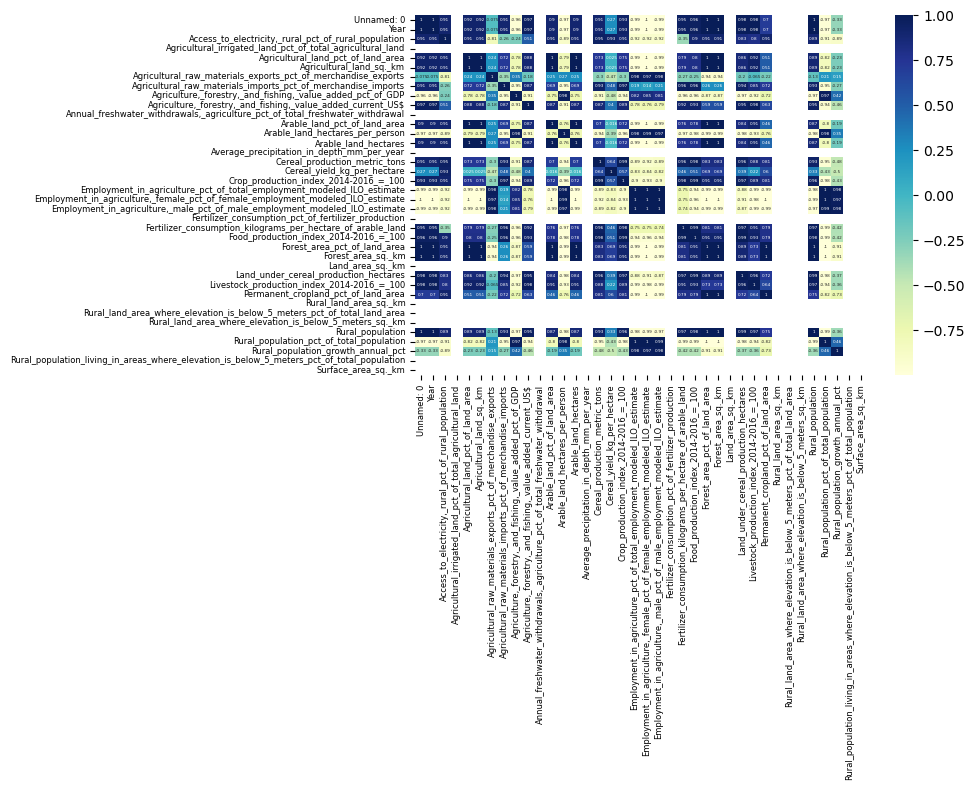

In [42]:
import matplotlib.pyplot as plt
co_mtx = ag_data.corr(numeric_only= True)

plt.figure(figsize=(10, 8)) 
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, annot_kws={"size": 3})

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()